# Neural ODEs as a Bridge to Implicit Layers

A neural ODE represents hidden evolution by

$$
\frac{dh(t)}{dt}=v_\theta(h(t),t).
$$

With explicit Euler and a time-independent vector field,

$$
h_{k+1}=h_k+\Delta t\,v_\theta(h_k).
$$

This is not a DEQ solve by itself, but it gives a useful bridge: both ODEs and
DEQs describe computation through an operator applied repeatedly. ODEs track a
finite-time path; DEQs solve for a time-independent equilibrium.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [3](https://jseluis.github.io/silva-networks/paper/references/#ref-3), [7](https://jseluis.github.io/silva-networks/paper/references/#ref-7). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import resolve_device, SolverConfig

torch.manual_seed(7)
np.random.seed(7)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## A Rotating-Damped Vector Field

For a hand-checkable example, let

$$
v(h)=Ah,
\qquad
A=\begin{bmatrix}-0.15 & -1\\ 1 & -0.15\end{bmatrix}.
$$

The first Euler update is

$$
h_1
=h_0+\Delta t Ah_0.
$$

With $h_0=(1,0)$ and $\Delta t=0.1$,

$$
Ah_0=(-0.15,1),
\qquad
h_1=(0.985,0.1).
$$

In [3]:
from silva_networks import SILVAEulerFlowBlock

class LinearVectorField(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.A = torch.nn.Parameter(torch.tensor([[-0.15, -1.0], [1.0, -0.15]]), requires_grad=False)

    def forward(self, h):
        return h @ self.A.T

ode = SILVAEulerFlowBlock(2, steps=50, step_size=0.1, vector_field=LinearVectorField()).to(device)
h0 = torch.tensor([[1.0, 0.0]], device=device)
terminal, trajectory = ode(h0, return_trajectory=True)
trajectory_xy = trajectory[:, 0].detach().cpu().numpy()
trajectory_xy[:3], terminal.detach().cpu().numpy()

(array([[1.      , 0.      ],
        [0.985   , 0.1     ],
        [0.960225, 0.197   ]], dtype=float32),
 array([[ 0.20607567, -0.5708824 ]], dtype=float32))

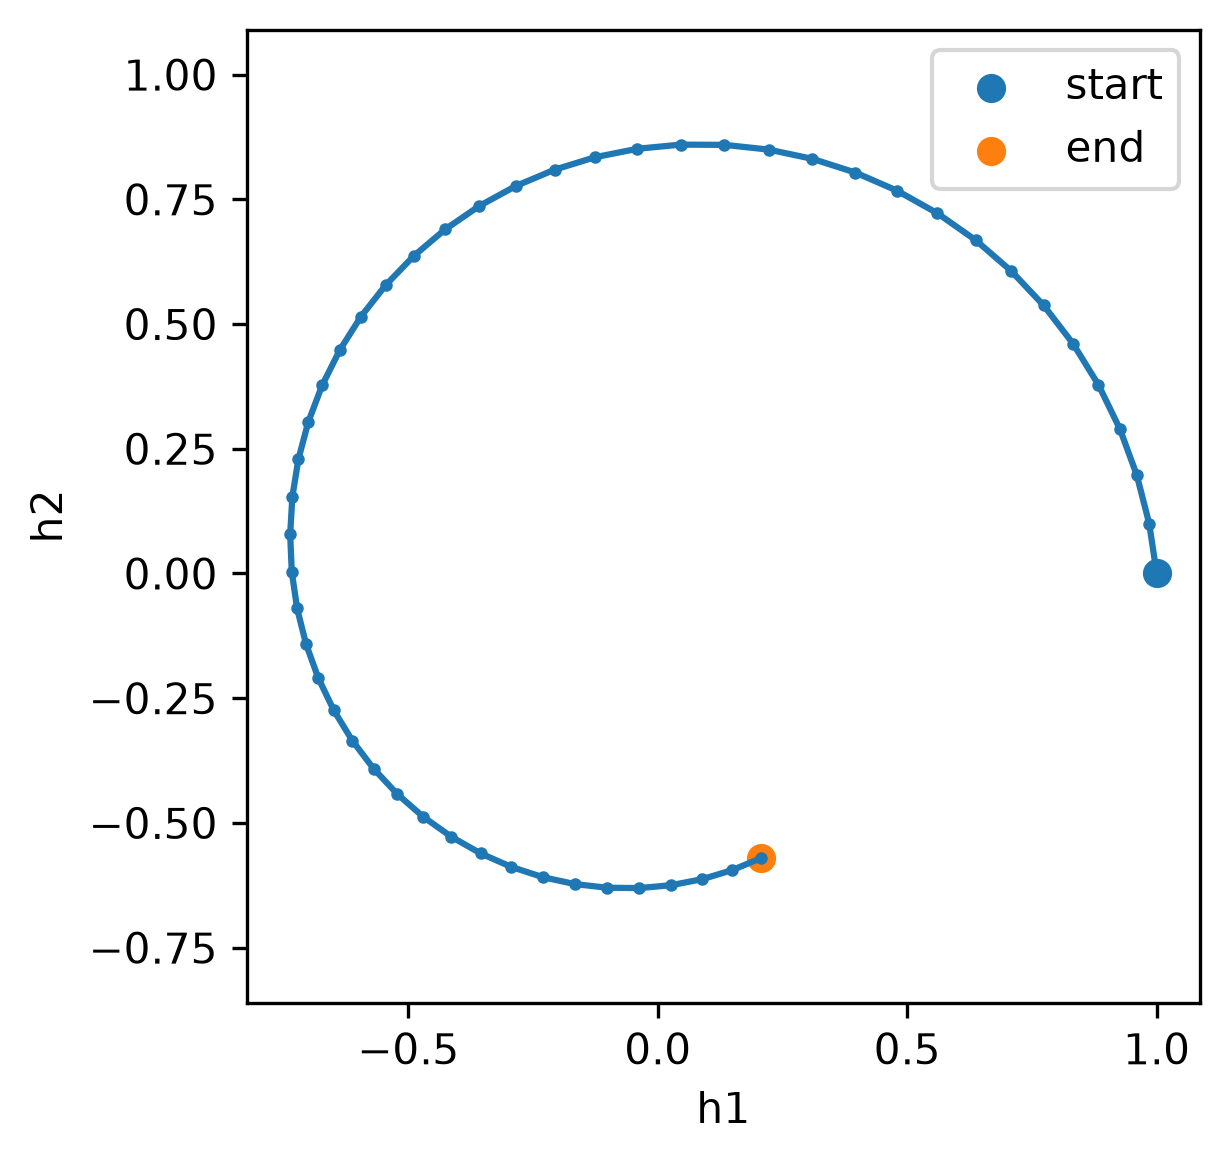

In [4]:
plt.figure(figsize=(4.2, 4.0))
plt.plot(trajectory_xy[:, 0], trajectory_xy[:, 1], marker="o", markersize=2)
plt.scatter([trajectory_xy[0, 0]], [trajectory_xy[0, 1]], label="start")
plt.scatter([trajectory_xy[-1, 0]], [trajectory_xy[-1, 1]], label="end")
plt.axis("equal")
plt.xlabel("h1")
plt.ylabel("h2")
plt.legend()
plt.tight_layout()

## Trainable ODE Block

`SILVAEulerFlowBlock` accepts a trainable vector field. It is an ordinary
PyTorch module, so gradients flow through every Euler step.

In [5]:
x = torch.randn(16, 3, device=device)
y = (x[:, 0] > 0).long()
feature = torch.nn.Linear(3, 8).to(device)
flow = SILVAEulerFlowBlock(8, hidden_dim=16, steps=5, step_size=0.15).to(device)
head = torch.nn.Linear(8, 2).to(device)
optim = torch.optim.Adam(list(feature.parameters()) + list(flow.parameters()) + list(head.parameters()), lr=0.02)

losses = []
for _ in range(6):
    optim.zero_grad()
    h = torch.tanh(feature(x))
    logits = head(flow(h))
    loss = torch.nn.functional.cross_entropy(logits, y)
    loss.backward()
    optim.step()
    losses.append(float(loss.detach().cpu()))

losses

[1.1033633947372437,
 0.9326790571212769,
 0.8089427947998047,
 0.7153202891349792,
 0.638888955116272,
 0.5718926191329956]

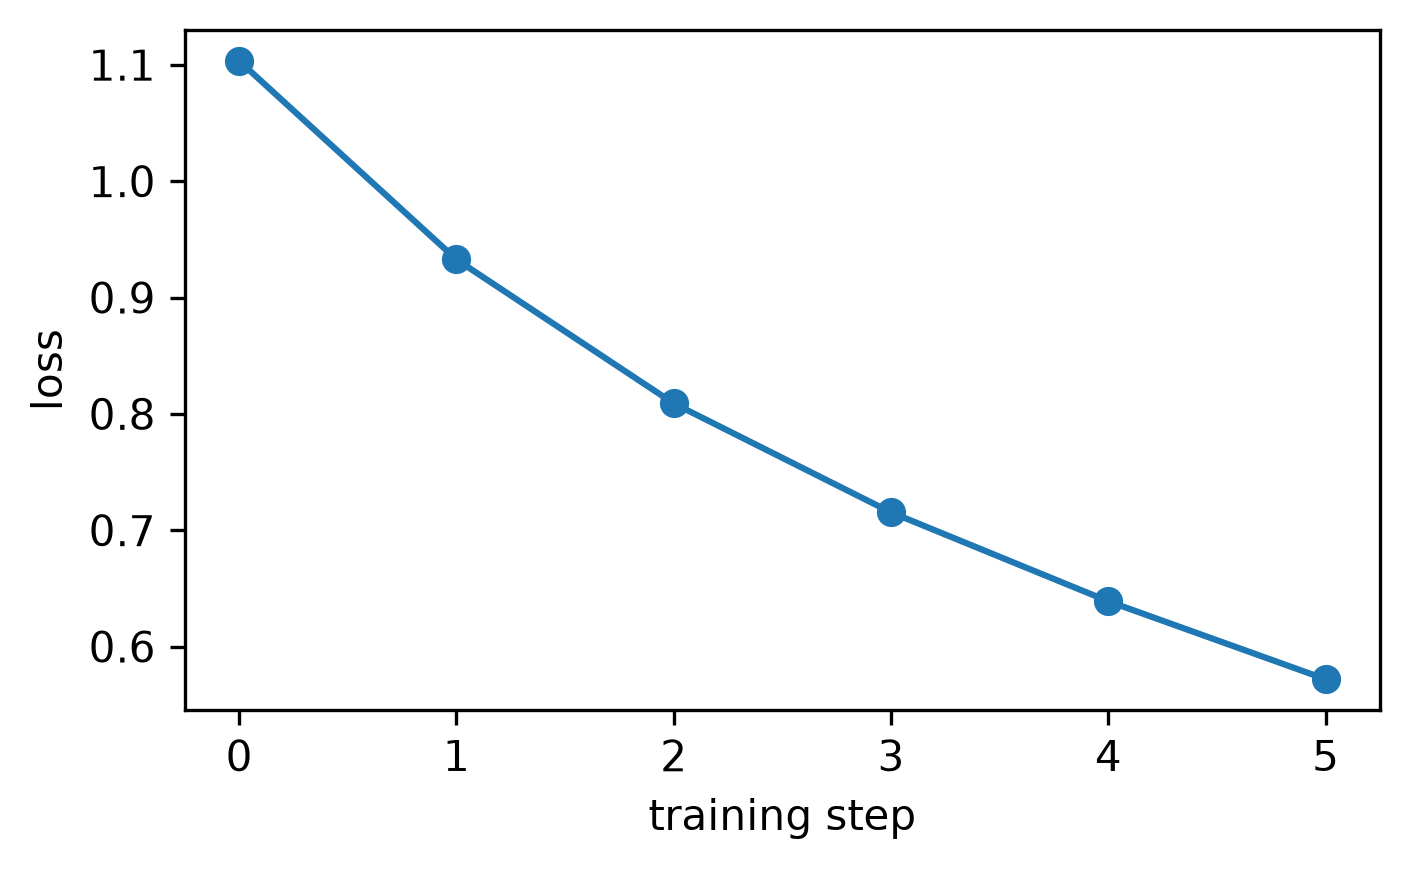

In [6]:
plt.figure(figsize=(4.8, 3.0))
plt.plot(losses, marker="o")
plt.xlabel("training step")
plt.ylabel("loss")
plt.tight_layout()

## Citation and Sources

If this package or notebook is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.1.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA methodology, cite the SILVA Networks
paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background sources:

- Deep Implicit Layers tutorial: https://implicit-layers-tutorial.org/
- LocusLab DEQ repository: https://github.com/locuslab/deq
- Deep Equilibrium Models: https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models: https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization: https://arxiv.org/abs/2106.14342

The notebook is adapted to the `silva_networks` public API. It links to the
sources above and keep the examples package-native.

## From 03 Neural Odes As Implicit Layers to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the evolving or terminal physical state |
| Condition | time, initial condition, and external forcing |
| Repeated computation | an explicit flow step or residual field T(z, x) - z |
| Required invariants | time-step shape, initial condition, and integration consistency |
| Replaceable components | vector field, integrator, equilibrium transition, readout, and tolerances |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [7]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**trajectory error, terminal fixed-point residual, and conservation error**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **time horizon, step count, state dimension, and stiffness**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [8]:
notebook_reproduction_record = {
    "notebook": '03_neural_odes_as_implicit_layers.ipynb',
    "state": 'the evolving or terminal physical state',
    "condition": 'time, initial condition, and external forcing',
    "transition": 'an explicit flow step or residual field T(z, x) - z',
    "invariants": 'time-step shape, initial condition, and integration consistency',
    "compact_metric": 'trajectory error, terminal fixed-point residual, and conservation error',
    "scale_axis": 'time horizon, step count, state dimension, and stiffness',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '03_neural_odes_as_implicit_layers.ipynb',
 'state': 'the evolving or terminal physical state',
 'condition': 'time, initial condition, and external forcing',
 'transition': 'an explicit flow step or residual field T(z, x) - z',
 'invariants': 'time-step shape, initial condition, and integration consistency',
 'compact_metric': 'trajectory error, terminal fixed-point residual, and conservation error',
 'scale_axis': 'time horizon, step count, state dimension, and stiffness'}

## Where to Go Next

| Question | Page |
| --- | --- |
| How do ODEs and implicit steps connect to SILVA? | [Neural Operators, ODEs, PDEs, and SILVA](https://jseluis.github.io/silva-networks/learn/neural-operators-ode-pde/) |
| How is this notebook situated in the bridge track? | [Implicit Layers Bridge](https://jseluis.github.io/silva-networks/learn/implicit-bridge/) |
| Which compact flow blocks are public? | [Implicit Bridge API](https://jseluis.github.io/silva-networks/api/implicit/) |
